# Diabetes Risk Dataset Exploratory Data Analyis (EDA)

### Dataset Description

The dataset used in this analysis is provided by `sklearn.datasets.load_diabetes()`. It contains medical and physiological measurements collected from patients and is commonly used for diabetes-related risk and progression studies.

### What Is Diabetes?

Diabetes is a chronic health condition where **blood glucose (blood sugar) levels are too high**. Normally, the hormone **insulin** — made by the pancreas — helps glucose enter cells to be used for energy. In diabetes, the body either **doesn’t make enough insulin, can’t use it properly, or both**. This causes glucose to build up in the bloodstream, which over time can damage organs such as the **heart, kidneys, eyes, and nerves**.

---

### Why Diabetes Becomes a Problem

The main problem in diabetes is **high blood glucose** that the body cannot regulate properly. This happens because:
- The pancreas produces **little or no insulin**.
- The body’s cells become **resistant to insulin** and can’t use glucose effectively. 

Over time, prolonged high blood sugar increases the risk for serious complications like heart disease, nerve damage, kidney disease, and vision problems. Managing blood glucose is therefore essential to reduce these risks.

---

### Common Types of Diabetes

#### **Type 1 Diabetes**
This is an **autoimmune condition** — the immune system destroys the insulin-producing cells in the pancreas. People with type 1 make little or no insulin and require **daily insulin treatment**. It often appears in children or young adults, but can occur at any age.

#### **Type 2 Diabetes**
The most common form (about 90–95% of cases), type 2 diabetes develops when the body **becomes resistant to insulin** and/or doesn’t produce enough of it. It is strongly linked to lifestyle and metabolic factors.

#### **Prediabetes**
A condition where blood glucose levels are higher than normal but not yet high enough to be diagnosed as type 2 diabetes. People with prediabetes have an increased risk of developing diabetes and heart disease.

---

### Major Risk Factors

Risk factors that increase the likelihood of developing diabetes — especially type 2 — include:
- **Family history** of diabetes  
- **Overweight or obesity**
- **Physical inactivity**
- Age (risk increases with age)
- Certain racial or ethnic backgrounds  
- A history of gestational diabetes  
- Conditions like high blood pressure and high cholesterol

---

### How Common Is Diabetes?

Diabetes affects a **large number of people worldwide**. For example, in the United States:
- Over **37 million people** (about 11% of the population) had diabetes in 2019.
- **More than 90%** of cases are type 2 diabetes.
- Millions more have **prediabetes**, with blood glucose levels above normal.

Globally, hundreds of millions of people are living with diabetes, and prevalence has been rising steadily over recent decades. 

## 1. Importing Packages and Checking Data

This section imports the necessary Python libraries used throughout the analysis, including tools for data manipulation, numerical computation, visualization, and machine learning.

The diabetes dataset is loaded from `sklearn.datasets`. This dataset provides physiological features and a target variable related to disease progression, which will be used for exploratory data analysis and binary classification modeling.

In [1]:
# Import the neccessary packages
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# Import the dataset to perform the EDA on
from sklearn.datasets import load_diabetes

In [2]:
# Load the data and checking the overall look
diabetes_data = load_diabetes()
diabetes_data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [3]:
# Check the given description of the data
print(diabetes_data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
df = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
df["target"] = diabetes_data.target
df.sample(5)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
123,0.005383,0.050680,0.034751,-0.001091,0.152538,0.198788,-0.061809,0.185234,0.015568,0.073480,84.0
389,-0.005515,0.050680,0.001339,-0.084856,-0.011201,-0.016658,0.048640,-0.039493,-0.041176,-0.088062,51.0
341,0.030811,0.050680,0.059541,0.056301,-0.022208,0.001191,-0.032356,-0.002592,-0.024795,-0.017646,263.0
276,0.012648,-0.044642,0.026128,0.063187,0.125019,0.091691,0.063367,-0.002592,0.057573,-0.021788,283.0
301,-0.001882,0.050680,-0.024529,0.052858,0.027326,0.030001,0.030232,-0.002592,-0.021395,0.036201,65.0


### 1.1 Dataset Preparation

Based on the dataset description and inspection of the sample values, the data appears to have been **mean-centered**.

For clearer interpretation, we will instead use the **original dataset prior to mean centering for EDA**.

**Prior mean-centering dataset:**  
https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt

In [5]:
# If viewed on mac to bypass SSL cert problem:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

original_data_url = "https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt"

original_data_df = pd.read_csv(original_data_url, sep="\t")
original_data_df.sample(5)

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
204,79,2,27.0,103.0,169,110.8,37.0,5.0,4.6634,110,277
266,34,2,20.6,98.0,183,92.0,83.0,2.0,3.6889,92,45
337,54,2,25.2,115.0,181,120.0,39.0,5.0,4.7005,92,91
207,51,1,30.6,103.0,198,106.6,57.0,3.0,5.1475,100,202
186,26,2,30.3,89.0,218,152.2,31.0,7.0,5.1591,82,137


In [6]:
# Check the shape of the dataset
print(f"Shape of the original dataset: {original_data_df.shape}")
print("---")

# Check for NULL / NaN values
print(
    "Number of NULL data points in each column:\n"
    f"{original_data_df.isna().sum()}"
)
print("---")

# Check for duplicated rows
print(
    f"Number of duplicated rows inside the dataset: "
    f"{original_data_df.duplicated().sum()}"
)

Shape of the original dataset: (442, 11)
---
Number of NULL data points in each column:
AGE    0
SEX    0
BMI    0
BP     0
S1     0
S2     0
S3     0
S4     0
S5     0
S6     0
Y      0
dtype: int64
---
Number of duplicated rows inside the dataset: 0


In [7]:
original_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGE     442 non-null    int64  
 1   SEX     442 non-null    int64  
 2   BMI     442 non-null    float64
 3   BP      442 non-null    float64
 4   S1      442 non-null    int64  
 5   S2      442 non-null    float64
 6   S3      442 non-null    float64
 7   S4      442 non-null    float64
 8   S5      442 non-null    float64
 9   S6      442 non-null    int64  
 10  Y       442 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 38.1 KB


In [8]:
original_data_df.describe()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


### 1.2 Target Variable Analysis

The target variable **Y** represents a **quantitative measure of disease progression one year after baseline**. It is a continuous variable ranging from 25 to 346, with a mean of approximately 152 and a standard deviation of ~77, indicating considerable variability in disease progression across patients.



scenario_1
Not Endangered    242
Endangered        200
Name: count, dtype: int64


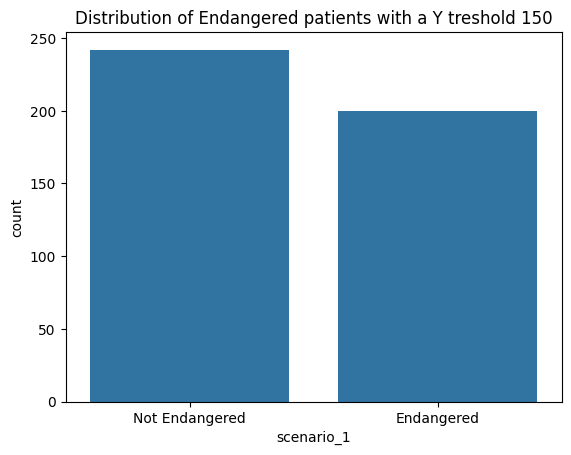

In [9]:
# Check the distributio of data based on the two tresholds which is 150 and 250

original_data_df['scenario_1'] = original_data_df['Y'].gt(150).map({True: "Endangered", False: "Not Endangered"})
print(original_data_df['scenario_1'].value_counts())

sns.countplot(x='scenario_1', data=original_data_df, order=['Not Endangered', 'Endangered'])
plt.title('Distribution of Endangered patients with a Y treshold 150')
plt.show()

# Save figure for use later
# plt.savefig('../docs/figures/target_variable_analysis/scenarion_1_countplot')

scenario_2
Not Endangered    377
Endangered         65
Name: count, dtype: int64


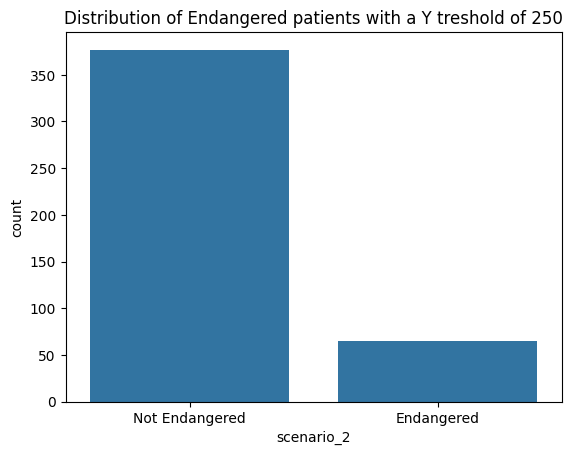

<Figure size 640x480 with 0 Axes>

In [10]:
original_data_df['scenario_2'] = original_data_df['Y'].gt(250).map({True: "Endangered", False: "Not Endangered"})
print(original_data_df['scenario_2'].value_counts())

sns.countplot(x='scenario_2', data=original_data_df, order=['Not Endangered', 'Endangered'])
plt.title('Distribution of Endangered patients with a Y treshold of 250')
plt.show()

# Save figure for use later
plt.savefig('../docs/figures/target_variable_analysis/scenarion_2_countplot')

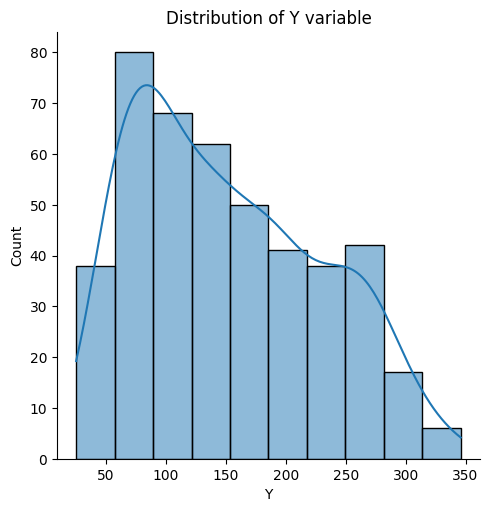

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: Y, dtype: float64

In [11]:
# Check the distribution of the "Y" variables data

sns.displot(original_data_df["Y"], kde=True)
plt.title("Distribution of Y variable")
plt.show()

# Save figure for use later
# plt.savefig('../docs/figures/target_variable_analysis/normal_distribution_displot')

# Check back the tendecies:
original_data_df['Y'].describe()

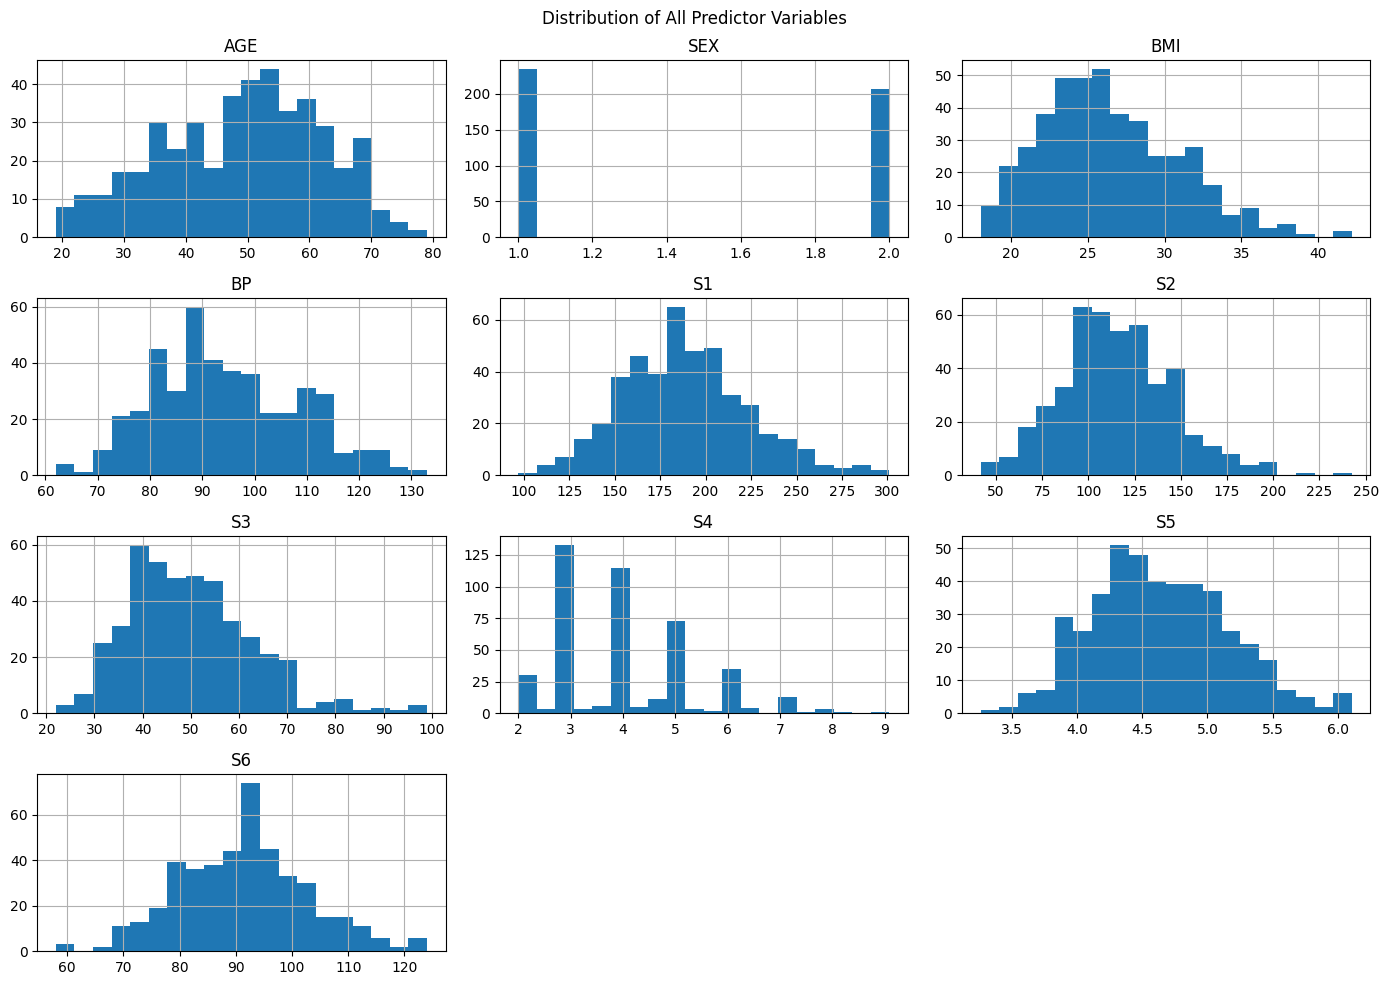

In [12]:
# Quick overview of all variables at once
original_data_df.drop(columns=['Y']).hist(figsize=(14, 10), bins=20)
plt.suptitle('Distribution of All Predictor Variables')
plt.tight_layout()
plt.show()

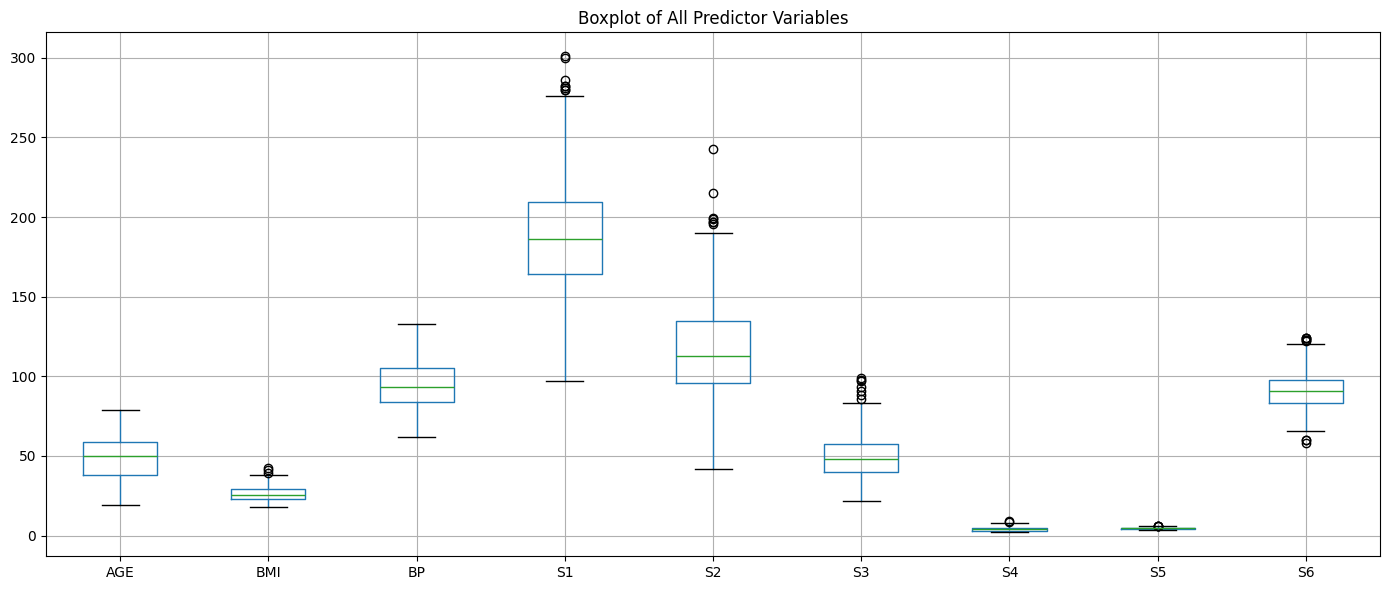

In [13]:
original_data_df.drop(columns=['Y', 'SEX']).boxplot(figsize=(14, 6))
plt.title('Boxplot of All Predictor Variables')
plt.tight_layout()
plt.show()

In [27]:
# IQR calculation for target variable Y
Q1 = original_data_df["Y"].quantile(0.25)
Q3 = original_data_df["Y"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Count outliers
outliers_Y = original_data_df[
    (original_data_df["Y"] < lower_bound) | 
    (original_data_df["Y"] > upper_bound)
]

print("Number of extreme outliers in Y:", len(outliers_Y))
print("Percentage of dataset:", round(len(outliers_Y) / len(original_data_df) * 100, 2), "%")

Q1: 87.0
Q3: 211.5
IQR: 124.5
Lower Bound: -99.75
Upper Bound: 398.25
Number of extreme outliers in Y: 0
Percentage of dataset: 0.0 %


In [30]:
# IQR-based outlier detection for all numeric columns
outlier_summary = {}

for col in original_data_df.drop(columns=['scenario_1','scenario_2']).columns:
    Q1 = original_data_df[col].quantile(0.25)
    Q3 = original_data_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = original_data_df[
        (original_data_df[col] < lower) | 
        (original_data_df[col] > upper)
    ]
    
    outlier_summary[col] = len(outliers)

# Convert to DataFrame for cleaner display
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
outlier_df["Outlier Percentage"] = (outlier_df["Outlier Count"] / len(original_data_df)) * 100

outlier_df.sort_values(by="Outlier Count", ascending=False)

,Outlier Count,Outlier Percentage
S6,9,2.036199
S1,8,1.809955
S2,7,1.583710
S3,7,1.583710
S5,4,0.904977
BMI,3,0.678733
S4,2,0.452489
AGE,0,0.000000
SEX,0,0.000000
BP,0,0.000000


### 1.5 Correlation and Multicollenarity check

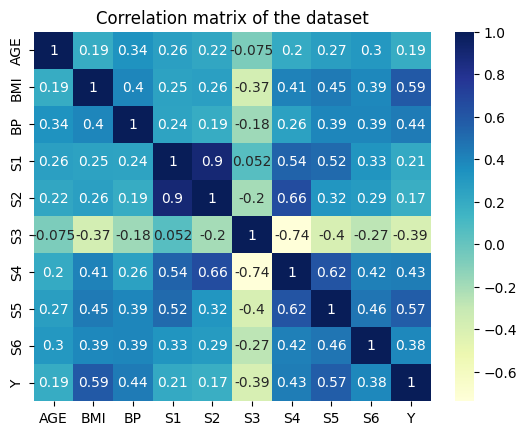

In [19]:
# Create the correlation matrix
co_mtx = original_data_df.drop(columns=["SEX"]).corr(numeric_only=True) 

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.title('Correlation matrix of the dataset')
plt.show()

<Axes: xlabel='BMI', ylabel='Y'>

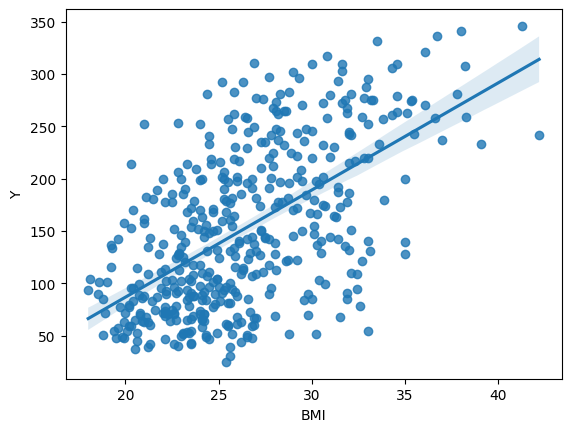

In [22]:
sns.regplot(x="BMI", y="Y", data=original_data_df)

<Axes: xlabel='S5', ylabel='Y'>

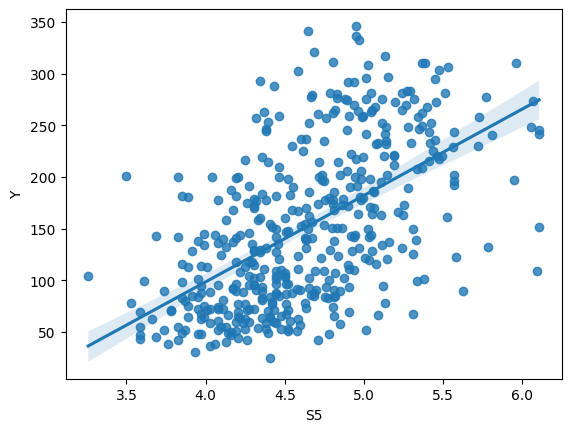

In [23]:
sns.regplot(x="S5", y="Y", data=original_data_df)

<Axes: xlabel='S3', ylabel='Y'>

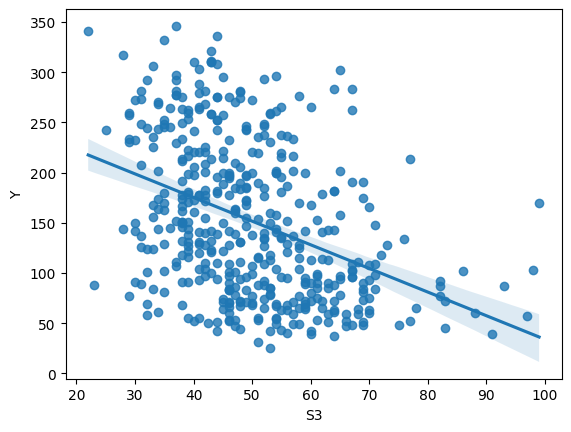

In [24]:
sns.regplot(x="S3", y="Y", data=original_data_df)

In [15]:
# Checking multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = original_data_df.drop(columns=["Y", "scenario_1", "scenario_2"]).astype(float)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]
vif_data

,feature,VIF
0,AGE,17.876909
1,SEX,12.192347
2,BMI,55.155355
3,BP,69.404363
4,S1,576.886424
5,S2,244.913298
6,S3,52.293365
7,S4,81.350054
8,S5,277.183350
9,S6,93.976986


<Axes: xlabel='SEX', ylabel='Y'>

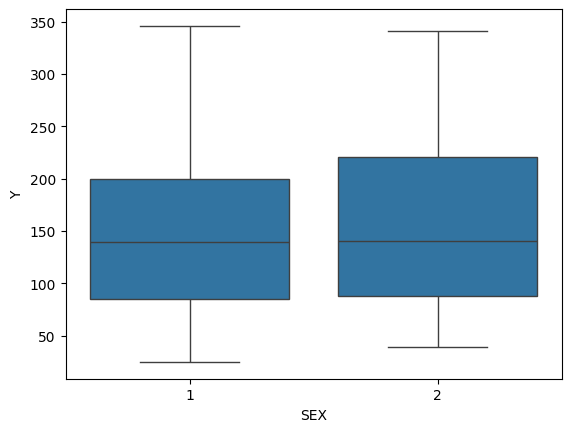

In [16]:
sns.boxplot(x="SEX", y="Y", data=original_data_df)

In [17]:
original_data_df.groupby("SEX")["Y"].mean()

SEX
1    149.021277
2    155.666667
Name: Y, dtype: float64